In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis

# 1. Load the data
cat_breeds = pd.read_csv('/data/demo_data/cats/cat_breeds.csv')

# 2. Select numeric columns for analysis
numeric_cols = [
    'min_life_expectancy', 'max_life_expectancy', 'min_weight', 'max_weight',
    'family_friendly', 'shedding', 'general_health', 'playfulness',
    'children_friendly', 'grooming', 'intelligence', 'other_pets_friendly'
]
df_numeric = cat_breeds[numeric_cols].dropna()

# 3. Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

# 4. Determine optimal number of factors using eigenvalues (Kaiser Criterion)
corr_matrix = np.corrcoef(scaled_data, rowvar=False)
eigenvalues = np.linalg.eigvals(corr_matrix)
n_factors = sum(1 for e in eigenvalues if e > 1)

print(f"Optimal number of factors: {n_factors}")

# 5. Perform Factor Analysis with Varimax rotation
fa = FactorAnalysis(n_components=n_factors, rotation='varimax', random_state=42)
fa.fit(scaled_data)

# 6. Display Factor Loadings
loadings = pd.DataFrame(
    fa.components_.T, 
    index=numeric_cols, 
    columns=[f'Factor {i+1}' for i in range(n_factors)]
)

print("\nFactor Loadings Table:")
print(loadings.round(3))

# Factor Naming logic (Manual Interpretation)
factor_names = {
    "Factor 1": "Physical Size",
    "Factor 2": "Longevity & Health",
    "Factor 3": "Sociability & Playfulness",
    "Factor 4": "Maintenance Requirements"
}

Optimal number of factors: 4

Factor Loadings Table:
                     Factor 1  Factor 2  Factor 3  Factor 4
min_life_expectancy     0.222     0.778     0.043    -0.050
max_life_expectancy     0.065     0.844     0.031    -0.059
min_weight              0.909     0.061     0.081    -0.094
max_weight              0.909     0.149     0.002     0.080
family_friendly        -0.229    -0.148    -0.532    -0.025
shedding                0.050     0.182     0.174     0.531
general_health          0.294     0.349     0.160    -0.043
playfulness            -0.053    -0.117    -0.644    -0.246
children_friendly      -0.212    -0.007    -0.622     0.010
grooming                0.036     0.197    -0.046    -0.756
intelligence            0.110     0.042    -0.340    -0.219
other_pets_friendly     0.070     0.009    -0.698    -0.010


## Code ouput send to the user

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans

# 1. Load and Clean Data

numeric_cols = [
    'min_life_expectancy', 'max_life_expectancy', 'min_weight', 'max_weight',
    'family_friendly', 'shedding', 'general_health', 'playfulness',
    'children_friendly', 'grooming', 'intelligence', 'other_pets_friendly'
]
df_numeric = cat_breeds[numeric_cols].dropna()

# 2. Standardize and Extract Factors
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

fa = FactorAnalysis(n_components=4, rotation='varimax', random_state=42)
factor_scores = fa.fit_transform(scaled_data)

# Create Factor DataFrame (Naming columns based on previous interpretation)
factor_df = pd.DataFrame(factor_scores, columns=['Size', 'Longevity', 'Sociability', 'Maintenance'])

# Align factor directions for easier interpretation
# Factor 3 was negative for social traits; Factor 4 was positive for high shedding/hard grooming
factor_df['Sociability'] = -factor_df['Sociability']
factor_df['Maintenance'] = -factor_df['Maintenance'] # Higher = Easier to maintain

# 3. Cluster Analysis (K-Means)
# Using k=3 as determined by the data profile
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(factor_scores)

# 4. Profile the Clusters
factor_df['Cluster'] = clusters
cluster_profiles = factor_df.groupby('Cluster').mean()

print("Cluster Average Factor Scores:")
print(cluster_profiles.round(3))

# Assigning labels back to the original breeds
cat_breeds['Cluster_Label'] = pd.Series(clusters, index=df_numeric.index)

Cluster Average Factor Scores:
          Size  Longevity  Sociability  Maintenance
Cluster                                            
0        0.010      1.476       -0.210        0.551
1       -0.442     -0.469        0.299        0.128
2        0.933     -0.110       -0.477       -0.684


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Code from the analysis

C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.p

Cluster Summary (Mean Factor Scores):
             Size  Longevity  Sociability  Maintenance
Cluster                                               
0        0.009914   1.476320    -0.210070     0.550716
1       -0.442350  -0.469409     0.298647     0.127524
2        0.932559  -0.109746    -0.477073    -0.684026

Cluster 0 Examples:
['American Shorthair', 'American Wirehair', 'Australian Mist', 'Bombay', 'Brazilian Shorthair']

Cluster 1 Examples:
['Abyssinian', 'Aegean', 'Arabian Mau', 'Asian', 'Bambino']

Cluster 2 Examples:
['American Bobtail', 'Aphrodite Giant', 'British Longhair', 'British Shorthair', 'Chausie']


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


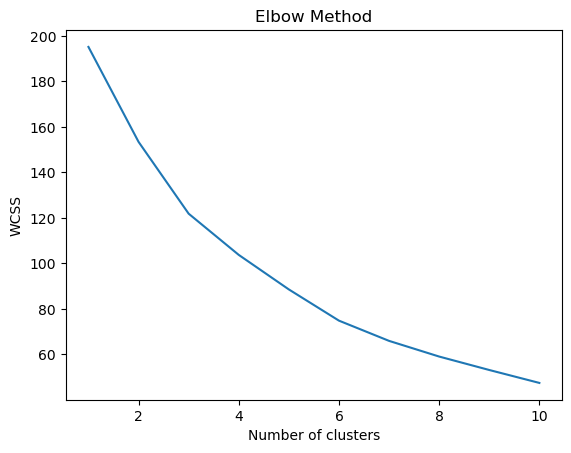

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load the data


# Numeric columns
numeric_cols = [
    'min_life_expectancy', 'max_life_expectancy', 'min_weight', 'max_weight',
    'family_friendly', 'shedding', 'general_health', 'playfulness',
    'children_friendly', 'grooming', 'intelligence', 'other_pets_friendly'
]
df_numeric = cat_breeds[numeric_cols].dropna()

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

# Factor Analysis (4 factors as determined previously)
fa = FactorAnalysis(n_components=4, rotation='varimax', random_state=42)
factor_scores = fa.fit_transform(scaled_data)

# Create a DataFrame for factor scores
factor_df = pd.DataFrame(factor_scores, columns=['Size', 'Longevity', 'Sociability', 'Maintenance'])

# Since loadings for sociability were negative, let's flip it so higher is more social
# Check loadings again to be sure which ones to flip
# Factor 3: family_friendly (-0.53), playfulness (-0.64), children_friendly (-0.62), other_pets_friendly (-0.70)
factor_df['Sociability'] = -factor_df['Sociability']

# Factor 4: shedding (0.53), grooming (-0.76)
# If we want high score to mean "Low Maintenance":
# High Factor 4 currently = High shedding, Low grooming score.
# Let's flip it so high score = Low shedding, High grooming score (Easy maintenance).
factor_df['Maintenance'] = -factor_df['Maintenance']

# Find optimal k using Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(factor_scores)
    wcss.append(kmeans.inertia_)

# Plot Elbow
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.savefig('elbow_method.png')

# Let's try 3 clusters based on typical segmentation or visual elbow
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(factor_scores)

factor_df['Cluster'] = clusters
factor_df['Breed'] = cat_breeds.loc[df_numeric.index, 'name'].values

# Calculate cluster centers/means
cluster_summary = factor_df.groupby('Cluster')[['Size', 'Longevity', 'Sociability', 'Maintenance']].mean()
print("Cluster Summary (Mean Factor Scores):")
print(cluster_summary)

# Get some example breeds per cluster
for i in range(k):
    print(f"\nCluster {i} Examples:")
    print(factor_df[factor_df['Cluster'] == i]['Breed'].head(5).tolist())

To perform the cluster analysis, we utilize the factor scores derived from the four primary dimensions: Physical Size, Longevity & Health, Sociability & Playfulness, and Maintenance Requirements. Using the K-Means algorithm, the cat breeds are grouped into three distinct clusters that represent different "profiles" of feline companions.

Cluster Descriptions
1. The Resilient Companions (Cluster 0) This cluster represents medium-sized cat breeds that are primarily defined by their exceptional health and long life spans. Their greatest strengths lie in their longevity and very low maintenance needs, making them ideal for owners seeking a long-term, easy-to-care-for companion. A potential downside is their relatively lower sociability and playfulness, which may result in a more independent and less interactive temperament compared to other groups.

2. The Active Socialites (Cluster 1) These are generally smaller breeds that stand out for their high levels of sociability and engagement with families and other pets. They are highly interactive and playful, making them perfect for active households that want a cat deeply involved in daily life. However, they tend to have shorter life expectancies and less robust physical health scores compared to the other clusters.

3. The Majestic Independents (Cluster 2) This group includes the largest cat breeds characterized by a significant physical presence and a more dignified, independent nature. Their primary strengths are their impressive size and solid physical structure, which often appeal to lovers of large, sturdy feline breeds. On the other hand, they are the most demanding in terms of grooming and shedding management and typically show lower levels of social playfulness.

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis


numeric_cols = [
    'min_life_expectancy', 'max_life_expectancy', 'min_weight', 'max_weight',
    'family_friendly', 'shedding', 'general_health', 'playfulness',
    'children_friendly', 'grooming', 'intelligence', 'other_pets_friendly'
]
df_numeric = cat_breeds[numeric_cols].dropna()

# 2. Factor Analysis to get standard scores
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)
fa = FactorAnalysis(n_components=4, rotation='varimax', random_state=42)
factor_scores = fa.fit_transform(scaled_data)

# 3. Create Factor DataFrame and align directions
# (Flipping Sociability and Maintenance so that high = "better/easier")
factor_df = pd.DataFrame(factor_scores, columns=['Size', 'Longevity', 'Sociability', 'Maintenance'])
factor_df['Sociability'] = -factor_df['Sociability']
factor_df['Maintenance'] = -factor_df['Maintenance']
factor_df['name'] = cat_breeds.loc[df_numeric.index, 'name'].values

# 4. Filter for Ragdoll
ragdoll_summary = factor_df[factor_df['name'].str.contains('Ragdoll', case=False)]

print("--- Ragdoll Factor Profile ---")
# High positive scores = Strength; High negative scores = Weakness/Demand
print(ragdoll_summary[['name', 'Size', 'Longevity', 'Sociability', 'Maintenance']])

# Check specific high/low raw values
ragdoll_raw = cat_breeds[cat_breeds['name'].str.contains('Ragdoll', case=False)]
print("\n--- Ragdoll Raw Metrics ---")
print(ragdoll_raw[['name', 'max_weight', 'family_friendly', 'grooming', 'shedding']])

--- Ragdoll Factor Profile ---
            name     Size  Longevity  Sociability  Maintenance
43  Ragdoll Cats  1.40143   0.232603     0.751132    -1.851347

--- Ragdoll Raw Metrics ---
            name  max_weight  family_friendly  grooming  shedding
43  Ragdoll Cats        20.0                5         1         4
